In [ ]:
# ROC curves comparing the published mitochondrial mRNA structures from mitoDMS-MaP seq data with PRADA reactivities

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from Bio import SeqIO
from sklearn import metrics 

In [4]:
## 1. Fig 4e --- ---

In [2]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

In [3]:
coord = pd.read_csv('./Data/mitochondria_coordinates.csv',sep=',')

In [5]:
def get_AUROC(transcript,dotfile): 

    ### A. input files 

    dir = "./Data/"
    vitro = pd.read_csv(dir+'PRADA-MaP_living_cells_mitochondria_structure_profiles.txt',sep='\t')
    vitro = vitro[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
    vitro_flt = vitro[vitro['Sequence'] !='N']
    vitro_flt = vitro_flt.reset_index(drop=True)
    vitro_flt['Position'] = vitro_flt.index+1 
    
    ### B. select single gene 

    start = coord.loc[coord['Gene']==transcript, 'Start'].values[0]
    end = coord.loc[coord['Gene']==transcript, 'End'].values[0]
    print(start)
    print(end)
    gene = vitro_flt[(vitro_flt['Position']>=start) & (vitro_flt['Position']<=end)]
    gene['Position2'] = gene['Position'] - start + 1 

    ### C. get the benchmarker 

    dir_bench = './Data/bench/'
    bench = convert_dot(dir_bench+dotfile,transcript)

    ### D. combine data with bench 

    df = pd.merge(gene,bench, how='left',on=['Position2','Position2'])
    df = df[(df['Modified_effective_depth'] >=5000) & (df['Untreated_effective_depth'] >=5000)]
    flt=df[(df['base']=='T') | (df['base']=='U') | (df['base']=='G')]
    print(flt.shape)

    if transcript in ['ND3','ND4L_4','CYTB']: 
        flt = flt[:-2]
        print(flt.shape)
    else:
        flt=flt
    
    flt['transcript'] = transcript
    flt.to_csv('./Data/'+transcript+'_data_for_plot.csv',sep=',')

    ### E. PLOT AUROC 

    fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
    roc_auc_1 = metrics.auc(fpr_1, tpr_1)
    print(roc_auc_1)

    fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
        ax.tick_params(width = 2)
        
    plt.title('HEK-MTS in vitro \n'+transcript+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
    plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

    plt.legend(loc = 'lower right', fontsize = 18)
    plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate', fontsize = 20)
    plt.xlabel('False Positive Rate', fontsize = 20)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    
    dir_out = './Data/'
    plt.savefig(dir_out+'Fig4e_'+transcript+'_living_cells_AUC_reactivity.pdf',bbox_inches='tight', dpi=300)  

5899
7516
(682, 13)
0.7718248468222182


/tmp/ipykernel_129956/1765516451.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1
/tmp/ipykernel_129956/1765516451.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flt['transcript'] = transcript


7585
8268
(262, 13)
0.8067743067743067
9206
9991


/tmp/ipykernel_129956/1765516451.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1
/tmp/ipykernel_129956/1765516451.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flt['transcript'] = transcript
/tmp/ipykernel_129956/1765516451.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

(317, 13)
0.8244591107582375
3304
4262
(208, 13)
0.8260649087221095


...

/tmp/ipykernel_129956/1765516451.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1
/tmp/ipykernel_129956/1765516451.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1


12336
14147
(465, 13)
0.7432043343653251
8364
9205


/tmp/ipykernel_129956/1765516451.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flt['transcript'] = transcript
/tmp/ipykernel_129956/1765516451.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1
/tmp/ipykernel_129956/1765516451.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

(273, 13)
0.8207867630944554
14746
15888
(394, 13)
(392, 13)
0.7852932050884268


/tmp/ipykernel_129956/1765516451.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1


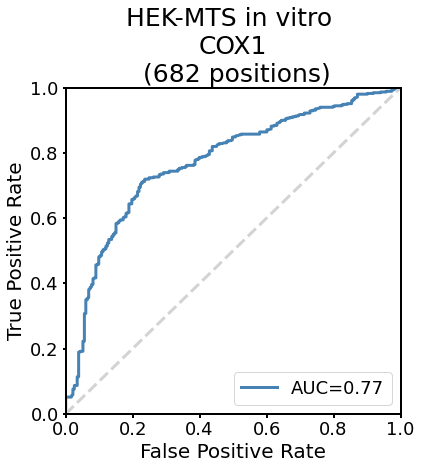

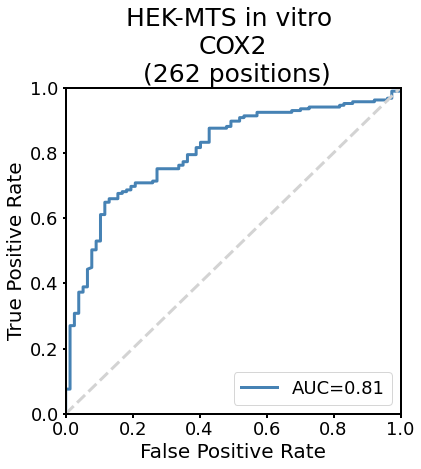

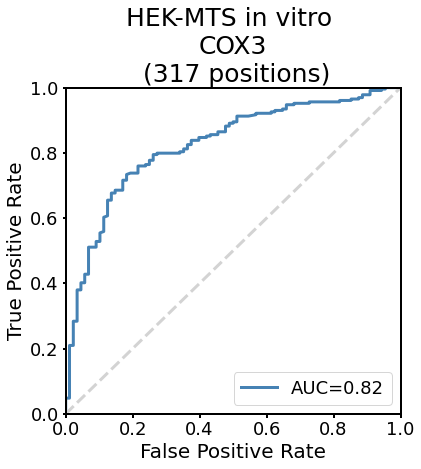

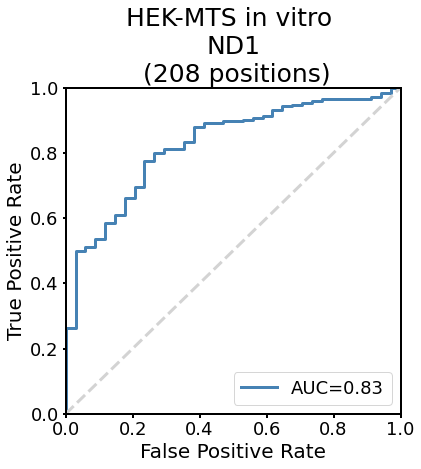

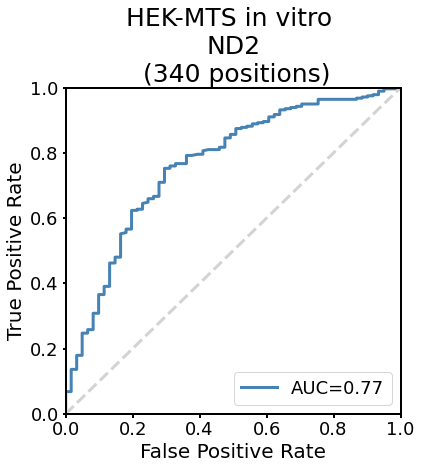

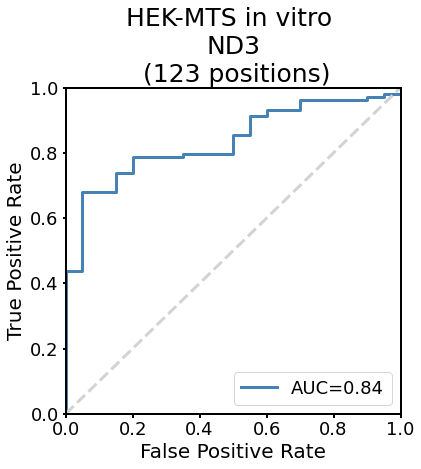

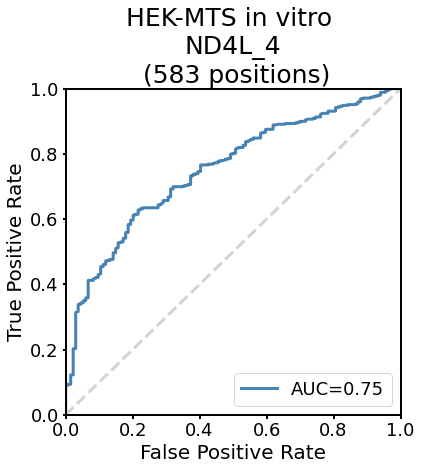

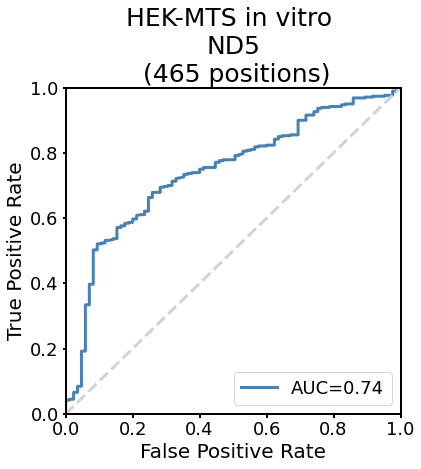

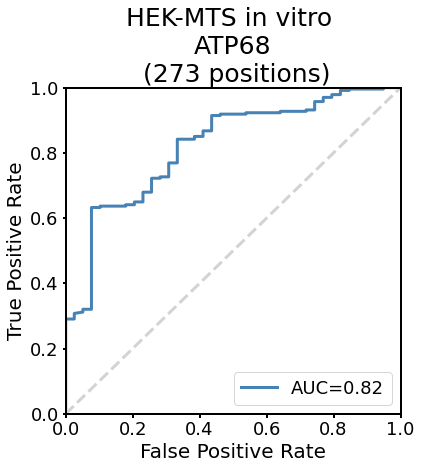

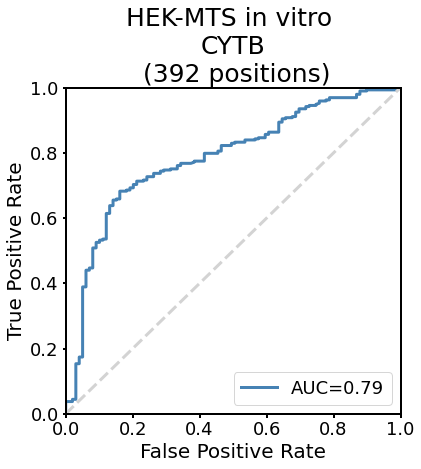

In [6]:
get_AUROC('COX1','bench_positive_COX1_1_1618_162.dot')
get_AUROC('COX2','bench_positive_COX2_1_708_71.dot') 
get_AUROC('COX3','bench_positive_COX3_1_786_79.dot') 
get_AUROC('ND1', 'bench_positive_ND1_1_959_96.dot')  
get_AUROC('ND2', 'bench_positive_ND2_1_1044_104.dot') 

get_AUROC('ND3', 'bench_positive_ND3_1_348_35.dot')
get_AUROC('ND4L_4','bench_positive_ND4_4L_1_1670_167.dot') 
get_AUROC('ND5','bench_positive_ND5_1_1812_181.dot') 
get_AUROC('ATP68','bench_positive_ATP68_1_842_84.dot')
get_AUROC('CYTB','bench_positive_CYTB_1_1143_114.dot')  